In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, avg, to_date, month, year
import pandas as pd
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("AnalisisBatchVentas") \
    .getOrCreate()

print("Spark iniciado correctamente")

Spark iniciado correctamente


In [3]:
productos = [
    ("Laptop", "Tecnología", 2500000),
    ("Celular", "Tecnología", 1200000),
    ("Audífonos", "Tecnología", 180000),
    ("Silla Gamer", "Hogar", 650000),
    ("Escritorio", "Hogar", 480000),
    ("Camiseta", "Ropa", 70000),
    ("Zapatos", "Ropa", 180000),
    ("Maleta", "Accesorios", 220000),
    ("Reloj", "Accesorios", 350000),
    ("Tablet", "Tecnología", 900000)
]

ciudades = ["Bogotá", "Medellín", "Cali", "Barranquilla", "Cartagena", "Bucaramanga"]

data = []

fecha_inicio = datetime(2025, 1, 1)

for i in range(10000):
    producto, categoria, precio_base = random.choice(productos)
    ciudad = random.choice(ciudades)
    cantidad = random.randint(1, 5)
    precio_unitario = precio_base + random.randint(-50000, 50000)
    fecha = fecha_inicio + timedelta(days=random.randint(0, 364))

    data.append({
        "id_venta": i + 1,
        "fecha": fecha.strftime("%Y-%m-%d"),
        "producto": producto,
        "categoria": categoria,
        "ciudad": ciudad,
        "cantidad": cantidad,
        "precio_unitario": precio_unitario
    })

df_pandas = pd.DataFrame(data)

df_pandas.to_csv("ventas.csv", index=False)

df_pandas.head()

,id_venta,fecha,producto,categoria,ciudad,cantidad,precio_unitario
0,1,2025-07-12,Silla Gamer,Hogar,Bucaramanga,5,653564
1,2,2025-04-03,Laptop,Tecnología,Cali,5,2545103
2,3,2025-11-21,Silla Gamer,Hogar,Bucaramanga,2,601699
3,4,2025-03-19,Celular,Tecnología,Bucaramanga,1,1207335
4,5,2025-01-02,Silla Gamer,Hogar,Bucaramanga,3,622120


In [4]:
df = spark.read.csv("ventas.csv", header=True, inferSchema=True)

print("Esquema del dataset:")
df.printSchema()

print("Primeros registros:")
df.show(10)

Esquema del dataset:
root
 |-- id_venta: integer (nullable = true)
 |-- fecha: date (nullable = true)
 |-- producto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- precio_unitario: integer (nullable = true)

Primeros registros:
+--------+----------+-----------+----------+-----------+--------+---------------+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|
+--------+----------+-----------+----------+-----------+--------+---------------+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|        1207335|
|       5|2025-01-02|Silla Gamer|     Hogar|Bucaramanga|       3|         622120|
|       6|202

In [5]:
print("Cantidad de registros iniciales:", df.count())

df_clean = df.dropna()

print("Cantidad de registros después de eliminar nulos:", df_clean.count())

df_clean = df_clean.withColumn("fecha", to_date(col("fecha")))

print("Esquema después de limpieza:")
df_clean.printSchema()

print("Primeros registros limpios:")
df_clean.show(5)

Cantidad de registros iniciales: 10000
Cantidad de registros después de eliminar nulos: 10000
Esquema después de limpieza:
root
 |-- id_venta: integer (nullable = true)
 |-- fecha: date (nullable = true)
 |-- producto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- precio_unitario: integer (nullable = true)

Primeros registros limpios:
+--------+----------+-----------+----------+-----------+--------+---------------+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|
+--------+----------+-----------+----------+-----------+--------+---------------+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|  

In [7]:
df_transformado = df_clean.withColumn(
    "total_venta",
    col("cantidad") * col("precio_unitario")
)

df_transformado = df_transformado.withColumn("año", year(col("fecha")))
df_transformado = df_transformado.withColumn("mes", month(col("fecha")))

print("Dataset transformado:")
df_transformado.show(10)

Dataset transformado:
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|total_venta| año|mes|
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|    3267820|2025|  7|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|   12725515|2025|  4|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|    1203398|2025| 11|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|        1207335|    1207335|2025|  3|
|       5|2025-01-02|Silla Gamer|     Hogar|Bucaramanga|       3|         622120|    1866360|2025|  1|
|       6|2025-08-28|    Zapatos|      Ropa|     Bogotá|       4|         193661|     774644|2025|  8|
|       7|2025-06-23|     Laptop|Tecnología|  Carta

In [9]:
df_transformado = df_clean.withColumn(
    "total_venta",
    col("cantidad") * col("precio_unitario")
)

df_transformado = df_transformado.withColumn("año", year(col("fecha")))
df_transformado = df_transformado.withColumn("mes", month(col("fecha")))

print("Dataset transformado:")
df_transformado.show(10)

Dataset transformado:
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|total_venta| año|mes|
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|    3267820|2025|  7|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|   12725515|2025|  4|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|    1203398|2025| 11|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|        1207335|    1207335|2025|  3|
|       5|2025-01-02|Silla Gamer|     Hogar|Bucaramanga|       3|         622120|    1866360|2025|  1|
|       6|2025-08-28|    Zapatos|      Ropa|     Bogotá|       4|         193661|     774644|2025|  8|
|       7|2025-06-23|     Laptop|Tecnología|  Carta

In [10]:
ventas_categoria = df_transformado.groupBy("categoria") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por categoría:")
ventas_categoria.show()

Ingresos totales por categoría:
+----------+----------------+
| categoria|ingresos_totales|
+----------+----------------+
|Tecnología|     14104305721|
|     Hogar|      3454480599|
|Accesorios|      1766180698|
|      Ropa|       728502539|
+----------+----------------+



In [11]:
ventas_ciudad = df_transformado.groupBy("ciudad") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por ciudad:")
ventas_ciudad.show()

Ingresos totales por ciudad:
+------------+----------------+
|      ciudad|ingresos_totales|
+------------+----------------+
|      Bogotá|      3460825169|
|    Medellín|      3452181761|
|        Cali|      3389199911|
| Bucaramanga|      3273200469|
|Barranquilla|      3239337108|
|   Cartagena|      3238725139|
+------------+----------------+



In [12]:
ventas_mes = df_transformado.groupBy("mes") \
    .agg(
        count("*").alias("cantidad_ventas"),
        sum("total_venta").alias("ingresos_totales")
    ) \
    .orderBy("mes")

print("Cantidad de ventas e ingresos por mes:")
ventas_mes.show()

Cantidad de ventas e ingresos por mes:
+---+---------------+----------------+
|mes|cantidad_ventas|ingresos_totales|
+---+---------------+----------------+
|  1|            850|      1594011865|
|  2|            791|      1682909358|
|  3|            890|      1706075774|
|  4|            813|      1658466804|
|  5|            884|      1684081209|
|  6|            821|      1718547852|
|  7|            817|      1615712196|
|  8|            853|      1694471861|
|  9|            820|      1651137467|
| 10|            849|      1674303900|
| 11|            768|      1557139980|
| 12|            844|      1816611291|
+---+---------------+----------------+



In [14]:
ventas_producto = df_transformado.groupBy("producto") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por producto:")
ventas_producto.show()

Ingresos totales por producto:
+-----------+----------------+
|   producto|ingresos_totales|
+-----------+----------------+
|     Laptop|      7582077892|
|    Celular|      3334645506|
|     Tablet|      2666597307|
|Silla Gamer|      1988149645|
| Escritorio|      1466330954|
|      Reloj|      1094513797|
|     Maleta|       671666901|
|  Audífonos|       520985016|
|    Zapatos|       519449563|
|   Camiseta|       209052976|
+-----------+----------------+



In [15]:
ventas_categoria = df_transformado.groupBy("categoria") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por categoría:")
ventas_categoria.show()

Ingresos totales por categoría:
+----------+----------------+
| categoria|ingresos_totales|
+----------+----------------+
|Tecnología|     14104305721|
|     Hogar|      3454480599|
|Accesorios|      1766180698|
|      Ropa|       728502539|
+----------+----------------+



In [16]:
ventas_ciudad = df_transformado.groupBy("ciudad") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por ciudad:")
ventas_ciudad.show()

Ingresos totales por ciudad:
+------------+----------------+
|      ciudad|ingresos_totales|
+------------+----------------+
|      Bogotá|      3460825169|
|    Medellín|      3452181761|
|        Cali|      3389199911|
| Bucaramanga|      3273200469|
|Barranquilla|      3239337108|
|   Cartagena|      3238725139|
+------------+----------------+



In [17]:
ventas_mes = df_transformado.groupBy("mes") \
    .agg(
        count("*").alias("cantidad_ventas"),
        sum("total_venta").alias("ingresos_totales")
    ) \
    .orderBy("mes")

print("Cantidad de ventas e ingresos por mes:")
ventas_mes.show()

Cantidad de ventas e ingresos por mes:
+---+---------------+----------------+
|mes|cantidad_ventas|ingresos_totales|
+---+---------------+----------------+
|  1|            850|      1594011865|
|  2|            791|      1682909358|
|  3|            890|      1706075774|
|  4|            813|      1658466804|
|  5|            884|      1684081209|
|  6|            821|      1718547852|
|  7|            817|      1615712196|
|  8|            853|      1694471861|
|  9|            820|      1651137467|
| 10|            849|      1674303900|
| 11|            768|      1557139980|
| 12|            844|      1816611291|
+---+---------------+----------------+



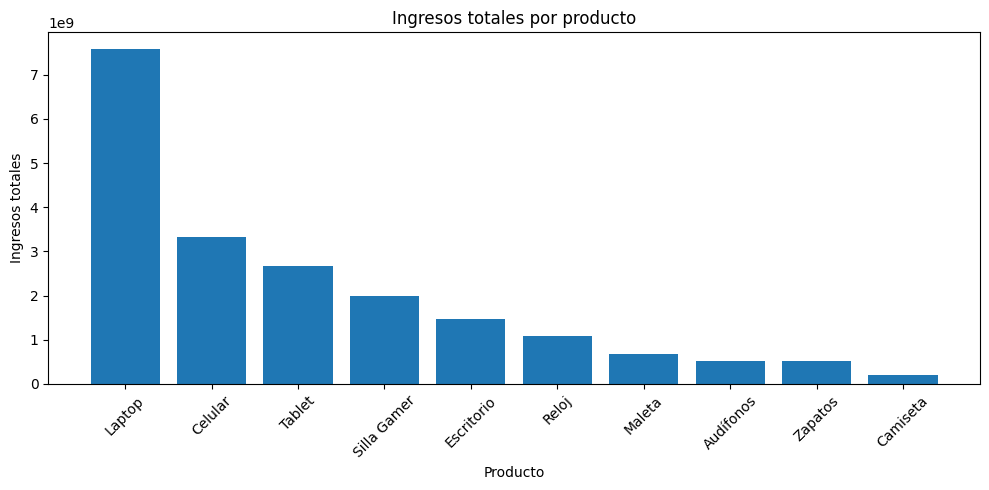

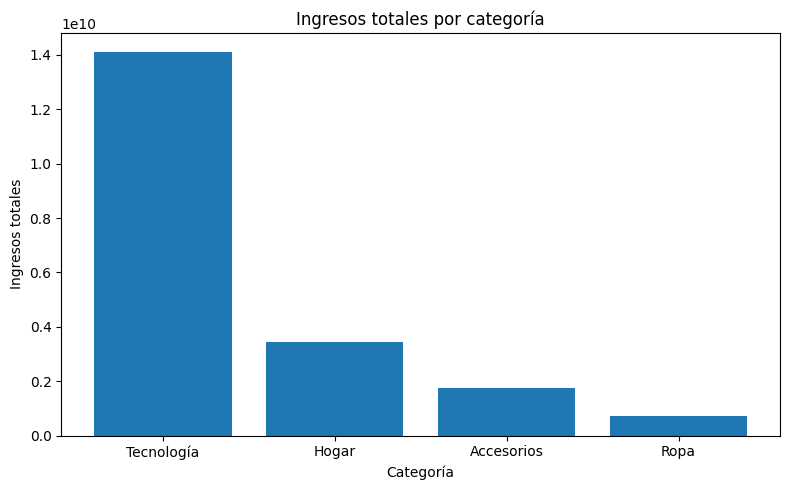

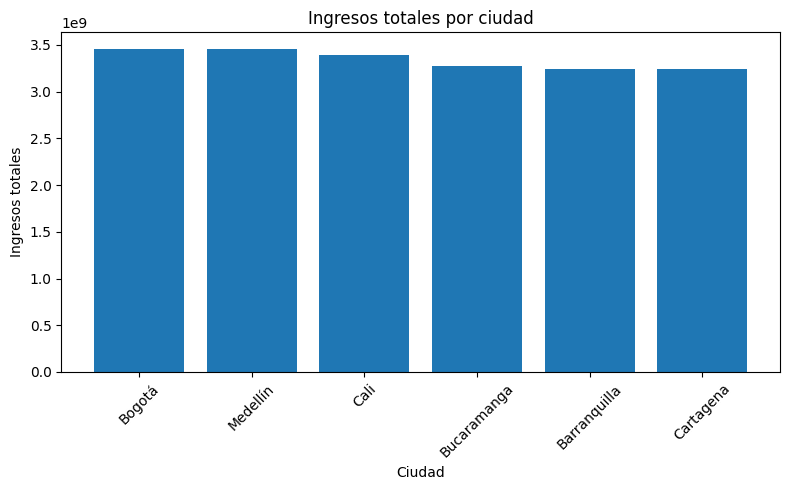

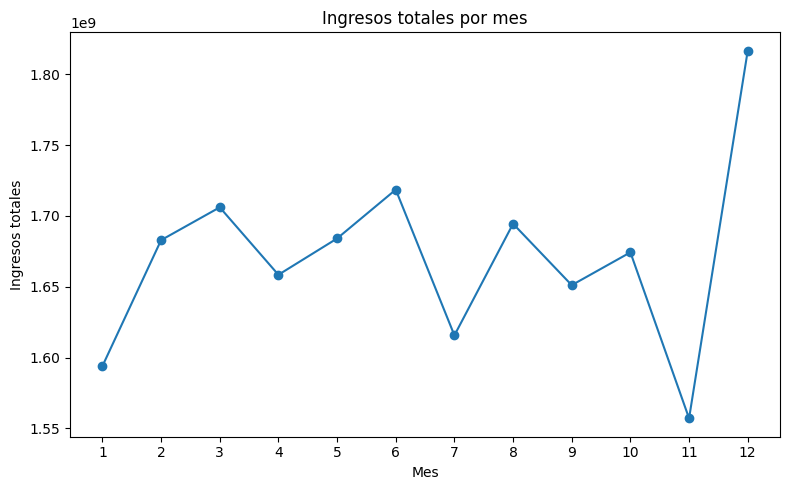

In [18]:
ventas_producto_pd = ventas_producto.toPandas()
ventas_categoria_pd = ventas_categoria.toPandas()
ventas_ciudad_pd = ventas_ciudad.toPandas()
ventas_mes_pd = ventas_mes.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(ventas_producto_pd["producto"], ventas_producto_pd["ingresos_totales"])
plt.title("Ingresos totales por producto")
plt.xlabel("Producto")
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(ventas_categoria_pd["categoria"], ventas_categoria_pd["ingresos_totales"])
plt.title("Ingresos totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos totales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(ventas_ciudad_pd["ciudad"], ventas_ciudad_pd["ingresos_totales"])
plt.title("Ingresos totales por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(ventas_mes_pd["mes"], ventas_mes_pd["ingresos_totales"], marker="o")
plt.title("Ingresos totales por mes")
plt.xlabel("Mes")
plt.ylabel("Ingresos totales")
plt.xticks(ventas_mes_pd["mes"])
plt.tight_layout()
plt.show()

In [19]:
ventas_producto.coalesce(1).write.csv("resultado_ventas_producto", header=True, mode="overwrite")
ventas_categoria.coalesce(1).write.csv("resultado_ventas_categoria", header=True, mode="overwrite")
ventas_ciudad.coalesce(1).write.csv("resultado_ventas_ciudad", header=True, mode="overwrite")
ventas_mes.coalesce(1).write.csv("resultado_ventas_mes", header=True, mode="overwrite")

print("Resultados exportados correctamente")

Resultados exportados correctamente
